In [1]:
import os # Configure which GPU
if os.getenv("CUDA_VISIBLE_DEVICES") is None:
    gpu_num = 2 # Use "" to use the CPU
    os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, ITURadioMaterial, SceneObject

import matplotlib.pyplot as plt

import mitsuba as mi

import numpy as np

# Import Sionna utils from the wireless class
try:
    import sionnautils
except ImportError as e:
    # Install Sionna if package is not already installed
    !pip install git+https://github.com/sdrangan/wirelesscomm.git
    import sionnautils
    
    
    
from scipy.spatial.transform import Rotation as R

from UE2_config import UE2

import mitsuba as mi
import drjit as dr
from sionna.rt import AntennaPattern, PlanarArray, register_antenna_pattern
from sionnautils.custom_scene import list_scenes, get_scene



Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def is_inside_building_mitsuba(scene, point, direction=np.array([0, 0, 1]), max_hits=50):
    """
    Casts a ray and counts intersections to determine if point is inside a mesh.
    """
    ray_origin = mi.Point3f(point)
    ray_dir = mi.Vector3f(direction)
    ray = mi.Ray3f(o=ray_origin, d=ray_dir)

    scene_mi = scene._scene  # Internal Mitsuba scene from Sionna

    count = 0
    for _ in range(max_hits):
        si = scene_mi.ray_intersect(ray, active=dr.ones(mi.Bool, 1)[0])
        if not si.is_valid():
            break
        count += 1
        ray.o = si.p + 1e-4 * ray.d  # Offset origin to avoid repeated self-hit

    return (count % 2 == 1)

def ue_inside_building(scene, point, direction=np.array([0, 0, 1]), max_hits=50):
    
    check_rx1 = is_inside_building_mitsuba(scene, point + np.array([-0.04,0.09,0]))
    check_rx2 = is_inside_building_mitsuba(scene, point + np.array([0.04,-0.09,0]))
    check_rx3 = is_inside_building_mitsuba(scene, point + np.array([0.04,0.09,0]))
    check_rx4 = is_inside_building_mitsuba(scene, point + np.array([-0.04,-0.09,0]))
    
    return check_rx1 and check_rx2 and check_rx3 and check_rx4

In [3]:
from matplotlib.path import Path

def is_point_in_region(region_vertices_3d, point_3d):

    point_xy = point_3d[:2]
    polygon_xy = region_vertices_3d[:, :2]
    path = Path(polygon_xy)
    return path.contains_point(point_xy)


In [4]:
from sionnautils.custom_scene import list_scenes, get_scene
scenes = list_scenes()
print(scenes)

scene_path, map_data = get_scene('nyu_tandon')
for k, v in map_data.items():
    print(f'{k}: {v}')

scene = load_scene(scene_path,merge_shapes=True)

floor = scene.get('ground')
# print(f'Floor material: {floor.radio_material.name}')
floor.radio_material = ITURadioMaterial("itu_concrete",
                                "concrete",
                                thickness=0.01,
                                color=(0.5, 0.5, 0.5))

scene.remove("itu_wet_ground")

for name, obj in scene.objects.items():
    print(f'{name:<15}{obj.radio_material.name}')
# scene.render(camera=my_cam, num_samples=512)

scene.radio_materials

['nyu_tandon']
bbox_lat: [40.69012764197041, 40.699120858029595]
bbox_long: [-73.99156687083165, -73.97970552916836]
address: 5 MetroTech Center, Brooklyn, NY 11201
descr: NYU Tandon campus
2026-01-20 16:20:55 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
no-name-1      itu_marble
ground         itu_concrete


{'itu_marble': ITURadioMaterial type=marble
                  eta_r=7.074
                  sigma=0.018
                  thickness=0.100
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000,
 'itu_concrete': ITURadioMaterial type=concrete
                  eta_r=5.240
                  sigma=0.123
                  thickness=0.010
                  scattering_coefficient=0.000
                  xpd_coefficient=0.000}

In [5]:
import gym
import numpy as np

# 42, 40, 226, 420, 812


# rand_seed = 812

# route 1_2
# rand_seed = 20250901

# route 1_3
# rand_seed = 812

# route 1_5
# rand_seed = 20250908


###########################################################
# route 1_6
# rand_seed = 20250912

#route 1_7
# rand_seed = 20250913

# 1_8
# rand_seed = 20250914

# 1_9
# rand_seed = 20250915

# 1_10
# rand_seed = 20250917

# 1_11
# rand_seed = 20250919

# 1_12
# rand_seed = 20250922

# 1_13
# rand_seed = 20250923

# 1_14
# rand_seed = 20250931

# 1_15
# rand_seed = 20250932


###########################################################
# route 1_21 to 40  V_max = 2mps
rand_seed = 21

# route 1_41 to 60 V_max = 5mps
# rand_seed = 48

# route 1_61 to 80 V_max = 10mps
# rand_seed = 80

file_route = "region_1_" + str(rand_seed) +"_60s_2mps_list.json"

# Constants
v = 1  # initial speed

v_max = 2
v_min = 0.0
dv_min, dv_max = -1, 1  # change in speed per seconds
dphi_min, dphi_max = -np.pi/4, np.pi/4  # change in angle per step
dt = 0.05  # time step in seconds

# Action space: [Δv, Δθ]
action_space = gym.spaces.Box(low=np.array([dv_min *dt, dphi_min *dt]),
                              high=np.array([dv_max *dt, dphi_max *dt]),
                              dtype=np.float64)
action_space.seed(rand_seed)
np.random.seed(rand_seed)


In [6]:

# Initial state
##### s1
# x, y, phi = 0, -50, np.pi 
# x, y, phi = -50, 8, np.pi / 2
# x, y, phi = 50, 30, 0 

##### region 1_1
# x, y, phi = -340, 562, np.pi /2

#### region 1_2 ...
x, y, phi = np.random.uniform(-388, -308), np.random.uniform(370, 460), np.random.uniform(-np.pi, np.pi)

n_ue = 2

route_list = []
for index_ue in range(n_ue):
    # Store trajectory
    trajectory = [(x, y, phi, v)]

    route = []
    xs = []
    ys = []
    vs = []
    angles = []

    time = 60
    n_steps = time / dt

    # # s1 region
    # region = np.array([[-125,35,1], [50,35,1],[50,-100,1],[-125,-100,1]])
    # tx_loc =[50,-115,10]
    # tx_loc =[-50,45,10]

    # s2 region 1
    region = np.array([[-428,352,1], [-308,352,1],[-308,500,1],[-428,500,1]])
    tx_loc =[-300,0,10]

    step = 0
    while step < n_steps:
        
        # if step % 100 == 0:
        #     print(step)
        
        # Sample action
        dv, dphi = action_space.sample()

        # Update speed and clip
        v = np.clip(v + dv, v_min, v_max)

        # Update heading
        phi += dphi

        # Update position
        temp_x = x + v * np.cos(phi) * dt
        temp_y = y+ v * np.sin(phi) * dt
        
        test_point = np.array([temp_x,temp_y,1]) 
        if ue_inside_building(scene, test_point) or (not is_point_in_region(region, test_point)):
            print(step)
            phi = phi + np.random.choice([-1, 1]) * np.pi / 6
            continue
        
        x = temp_x
        y = temp_y

        # # Store new state
        # if phi > np.pi:
        #     phi -= 2* np.pi
        # elif phi <= -np.pi:
        #     phi += 2* np.pi
        
        trajectory.append((x, y, phi, v))
        
        xs.append(x)
        ys.append(y)
        angles.append(phi)
        vs.append(v)
        
        
        
        route.append([x,y,1])
        step += 1
        
    route_list.append(route)

    # route_list = [route, route]
    # Print the trajectory
    for i, (x, y, phi, v) in enumerate(trajectory):
        print(f"UE {index_ue}, Step {i:2d}: x = {x:.3f}, y = {y:.3f}, phi = {phi:.3f}, v = {v:.3f}")


UE 0, Step  0: x = -384.102, y = 396.020, phi = 1.388, v = 1.000
UE 0, Step  1: x = -384.093, y = 396.070, phi = 1.397, v = 1.028
UE 0, Step  2: x = -384.082, y = 396.122, phi = 1.364, v = 1.049
UE 0, Step  3: x = -384.073, y = 396.174, phi = 1.402, v = 1.062
UE 0, Step  4: x = -384.063, y = 396.226, phi = 1.372, v = 1.055
UE 0, Step  5: x = -384.053, y = 396.280, phi = 1.386, v = 1.100
UE 0, Step  6: x = -384.044, y = 396.333, phi = 1.399, v = 1.070
UE 0, Step  7: x = -384.033, y = 396.388, phi = 1.376, v = 1.119
UE 0, Step  8: x = -384.023, y = 396.444, phi = 1.392, v = 1.155
UE 0, Step  9: x = -384.011, y = 396.500, phi = 1.367, v = 1.127
UE 0, Step 10: x = -383.999, y = 396.557, phi = 1.355, v = 1.172
UE 0, Step 11: x = -383.987, y = 396.614, phi = 1.367, v = 1.166
UE 0, Step 12: x = -383.973, y = 396.670, phi = 1.328, v = 1.160
UE 0, Step 13: x = -383.959, y = 396.725, phi = 1.325, v = 1.136
UE 0, Step 14: x = -383.945, y = 396.782, phi = 1.334, v = 1.163
UE 0, Step 15: x = -383.9

In [7]:
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Create transmitter
tx = Transmitter(name="tx",
                position=tx_loc,
                 display_radius=5)
scene.remove("tx")
scene.add(tx)

# scene.preview()


In [8]:
route_list[0]

[[-384.09310442860266, 396.07049776785544, 1],
 [-384.0823553910042, 396.1218391995799, 1],
 [-384.07344266752136, 396.1741941482801, 1],
 [-384.0630162742408, 396.22587815138974, 1],
 [-384.05288318659126, 396.2799534549468, 1],
 [-384.0437404730813, 396.3326689838207, 1],
 [-384.03292115463097, 396.387579433007, 1],
 [-384.02264607661914, 396.4443932529835, 1],
 [-384.01124918566984, 396.4995724389573, 1],
 [-383.99867454890835, 396.55682238490897, 1],
 [-383.9868620207714, 396.61393522438465, 1],
 [-383.97288941579905, 396.67025085950814, 1],
 [-383.95908524255447, 396.72537307931174, 1],
 [-383.9454353767216, 396.78187853282475, 1],
 [-383.93050863433274, 396.83769896935866, 1],
 [-383.91381349809575, 396.8945013093633, 1],
 [-383.8967910653533, 396.9523736735388, 1],
 [-383.87916610640553, 397.0103382874295, 1],
 [-383.86051250376977, 397.06641717247453, 1],
 [-383.84064078730034, 397.12282668323957, 1],
 [-383.8202753386443, 397.17646932443165, 1],
 [-383.8000899543702, 397.23242

In [9]:
scene.rx_array = PlanarArray(num_rows=1,
                              num_cols=1,
                              vertical_spacing=0.5,
                              horizontal_spacing=0.5,
                              pattern="iso",
                              polarization="V")


for idx in range(step):
    # print(idx)
    rx = Receiver(name=f"rx-{idx}",
              position=np.array(route[idx]),
              display_radius=1)
    scene.remove(f"rx-{idx}")
    scene.add(rx)
    
# for idx in range(len(region)):
#     # print(idx)
#     rx = Receiver(name=f"region-{idx}",
#               position=np.array(region[idx]),
#               display_radius=2)
#     scene.add(rx)

In [10]:
# # Create new camera with different configuration
# my_cam = Camera(position=[-320,430,500], look_at=[-320,430,0])
# scene.render(camera=my_cam, resolution=[50,50])
scene.preview()


In [11]:
measure_index = range(int(n_steps))
measure_index

range(0, 1200)

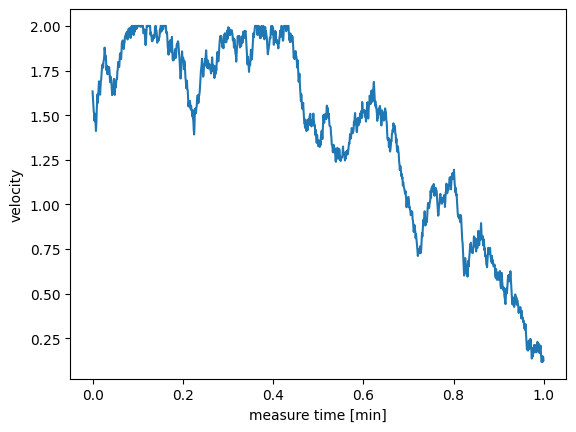

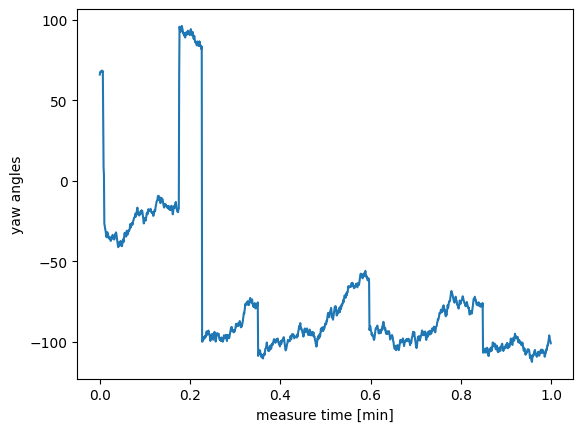

In [12]:


plt.figure()

plt.plot(np.array(measure_index) * dt / 60, np.array(vs), label=f"yaw angle")

# plt.legend(loc = "lower left")
plt.xlabel("measure time [min]")
plt.ylabel("velocity")
# plt.ylim(-75,-60)
plt.show()

plt.figure()

plt.plot(np.array(measure_index) * dt / 60, np.array(angles) / (2*np.pi) * 360, label=f"yaw angle")

# plt.legend(loc = "lower left")
plt.xlabel("measure time [min]")
plt.ylabel("yaw angles")
# plt.ylim(-75,-60)
plt.show()

In [13]:
import json

# file_route = "region_1_" + str(rand_seed) +"_60s_10mps_list.json"
with open(file_route, 'w') as f:
    json.dump(route_list, f)
